# 01 — Load & Inspect Dataset\n
\n
Put these files in `data/raw/` before running:\n
- `Fake.csv`\n
- `True.csv`\n

In [2]:
import pandas as pd
import numpy as np

pd.set_option("display.max_colwidth", 200)

In [3]:
fake_df = pd.read_csv("../data/raw/Fake.csv")
true_df = pd.read_csv("../data/raw/True.csv")

print("Fake news shape:", fake_df.shape)
print("True news shape:", true_df.shape)

Fake news shape: (23481, 4)
True news shape: (21417, 4)


In [4]:
fake_df["label"] = 0   # fake
true_df["label"] = 1   # real

In [5]:
df = pd.concat([fake_df, true_df], axis=0)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df.head()


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committed a ‘Coup d’état’ Against the Constitution,"21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off) made some provocati...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Security Council,"WASHINGTON (Reuters) - U.S. President Donald Trump removed his chief strategist Steve Bannon from the National Security Council on Wednesday, reversing his controversial decision early this year t...",politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shipping restrictions,"(Reuters) - Puerto Rico Governor Ricardo Rossello said on Wednesday he expected the federal government to waive the Jones Act, which would lift restrictions on ships that can provide aid to the is...",politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Leaked Israeli Intelligence To Russia (VIDEO),"On Monday, Donald Trump once again embarrassed himself and his country by accidentally revealing the source of the extremely classified information he leaked to Russia earlier this month.While it ...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a golf resort,"GLASGOW, Scotland (Reuters) - Most U.S. presidential candidates go abroad to sharpen their foreign policy credentials. Donald Trump arrives in Scotland on Friday to reopen a golf resort. The presu...",politicsNews,"June 24, 2016",1


In [6]:
import re
import string
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", "", text)
    text = text.strip()
    words = text.split()
    words = [w for w in words if w not in ENGLISH_STOP_WORDS]
    return " ".join(words)

df["clean_text"] = df["text"].apply(clean_text)

df[["text", "clean_text"]].head()

,text,clean_text
0,"21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off) made some provocati...",st century wire says ben stein reputable professor pepperdine university hollywood fame appearing tv shows films ferris bueller s day provocative statements judge jeanine pirro s recently discussi...
1,"WASHINGTON (Reuters) - U.S. President Donald Trump removed his chief strategist Steve Bannon from the National Security Council on Wednesday, reversing his controversial decision early this year t...",washington reuters president donald trump removed chief strategist steve bannon national security council wednesday reversing controversial decision early year political adviser unprecedented role...
2,"(Reuters) - Puerto Rico Governor Ricardo Rossello said on Wednesday he expected the federal government to waive the Jones Act, which would lift restrictions on ships that can provide aid to the is...",reuters puerto rico governor ricardo rossello said wednesday expected federal government waive jones act lift restrictions ships provide aid island devastated hurricane maria said speaking members...
3,"On Monday, Donald Trump once again embarrassed himself and his country by accidentally revealing the source of the extremely classified information he leaked to Russia earlier this month.While it ...",monday donald trump embarrassed country accidentally revealing source extremely classified information leaked russia earlier monthwhile speculated source information israel trump things crystal cl...
4,"GLASGOW, Scotland (Reuters) - Most U.S. presidential candidates go abroad to sharpen their foreign policy credentials. Donald Trump arrives in Scotland on Friday to reopen a golf resort. The presu...",glasgow scotland reuters presidential candidates abroad sharpen foreign policy credentials donald trump arrives scotland friday reopen golf resort presumptive republican nominee visits family’s an...


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X = df["clean_text"]
y = df["label"]

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X_tfidf = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape


((35918, 5000), (8980, 5000))

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print(classification_report(y_test, y_pred))

Accuracy: 0.9908685968819599
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4696
           1       0.99      0.99      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



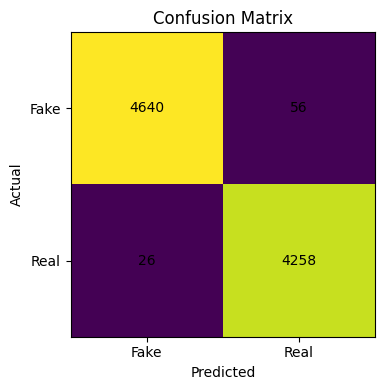

In [9]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
plt.imshow(cm)               # δεν ορίζω χρώμα
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0,1], ["Fake","Real"])
plt.yticks([0,1], ["Fake","Real"])

# γράφει τους αριθμούς μέσα στα κουτάκια
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

In [10]:
def credibility_score(text):
    clean = clean_text(text)
    vec = vectorizer.transform([clean])
    prob = model.predict_proba(vec)[0]
    
    fake_prob = prob[0]
    real_prob = prob[1]
    
    score = round(real_prob * 100, 2)
    return score


sample_text = df.iloc[0]["text"]
credibility_score(sample_text)


np.float64(0.62)

In [11]:
import os

os.makedirs("models", exist_ok=True)

import joblib

joblib.dump(model, "models/fake_news_model.pkl")
joblib.dump(vectorizer, "models/tfidf_vectorizer.pkl")

['models/tfidf_vectorizer.pkl']

Accuracy: 0.9908685968819599
              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      4696
        Real       0.99      0.99      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



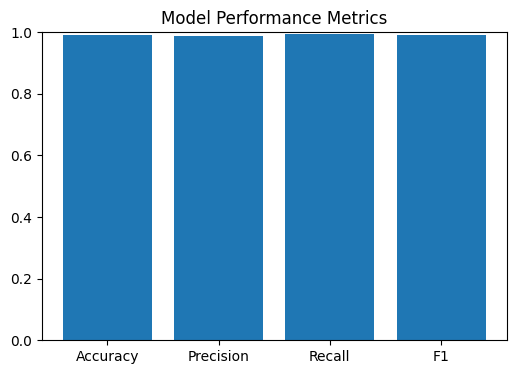

In [12]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["Fake","Real"]))




from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)

names = ["Accuracy","Precision","Recall","F1"]
values = [acc, precision, recall, f1]

plt.figure(figsize=(6,4))
plt.bar(names, values)
plt.ylim(0,1)
plt.title("Model Performance Metrics")
plt.show()

In [13]:
import numpy as np

def predict_with_confidence(text):
    clean = clean_text(text)
    vec = vectorizer.transform([clean])
    probs = model.predict_proba(vec)[0]          # [P(fake), P(real)]
    pred = int(np.argmax(probs))                 # 0 fake, 1 real
    confidence = float(np.max(probs))            # 0..1

    label = "Real" if pred==1 else "Fake"
    return label, round(confidence*100, 2)

sample_text = df.iloc[0]["text"]
predict_with_confidence(sample_text)


('Fake', 99.38)

In [14]:
import os, joblib

os.makedirs("models", exist_ok=True)

joblib.dump(model, "models/fake_news_model.pkl")
joblib.dump(vectorizer, "models/tfidf_vectorizer.pkl")


['models/tfidf_vectorizer.pkl']